# Macroeconomía Narrativa — Transcripciones Multilococtor, Tópicos Dinámicos y SVARs Bayesianos

**¿Cómo transformar sistemáticamente la comunicación de los bancos centrales y las discusiones en foros en choques macroeconómicos estructurales?**

La información textual contiene señales prospectivas sobre la postura monetaria, las expectativas de inflación y las presiones financieras emergentes.
En este tutorial interactivo exploramos el pipeline narrativo integral de `puremacro`:
1. **Procesamiento de Transcripciones Multilocutor**: Separación de declaraciones preparadas y la sesión interactiva de preguntas y respuestas (FOMC, BCE, Banxico).
2. **Modelado de Tópicos Dinámicos en Python Puro (NMF)**: Seguimiento temporal de temas macroeconómicos mediante factorización matricial no negativa.
3. **Detección de Anomalías y Ráfagas Narrativas**: Detección de picos estadísticos ($z$-scores) de términos clave antes de las publicaciones estadísticas oficiales.
4. **Identificación SVAR Narrativa Bayesiana**: Restricciones de magnitud de choque de Ludvigson–Ma–Ng (2021) y muestreador posterior Normal-Inversa-Wishart.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.narrative import (
    DynamicTopicModel,
    detect_narrative_bursts,
    score_spanish_macro_sentiment,
)
from puremacro.narrative.sources import parse_transcript
from puremacro.var.identify import NarrativeRestriction, narrative_sign_svar

## 1. Extracción de Transcripciones y Asimetría de Portavoces

En las conferencias de prensa de política monetaria, la **declaración de apertura** refleja el consenso institucional, mientras que las **respuestas a la prensa** revelan los matices del Gobernador bajo escrutinio periodístico.
`puremacro.narrative.sources.parse_transcript` segmenta el diálogo por rol y sección.

In [2]:
raw_transcript = """
CONFERENCIA DE PRENSA DE POLITICA MONETARIA
BANCO CENTRAL

GOBERNADOR: Buenas tardes. La Junta de Gobierno decidió por unanimidad incrementar la tasa de interés objetivo en 25 puntos base ante la presencia de presiones inflacionarias y la necesidad de consolidar el anclaje de las expectativas.

PREGUNTAS Y RESPUESTAS

PERIODISTA: ¿Qué factores en la actividad económica podrían acelerar el ciclo de recortes de tasas?

GOBERNADOR: Evaluaremos la postura restrictiva y la velocidad de convergencia inflacionaria hacia la meta del 3 por ciento.
"""

doc = parse_transcript(raw_transcript, title="Conferencia de Prensa Banxico", institution="BANXICO")
print(f"Documento procesado: {doc.title} con {len(doc.turns)} turnos de palabra.")
print(f"Palabras en declaración preparada: {len(doc.opening_statement().split())}")
print(f"Palabras en respuestas Q&A:         {len(doc.chair_qa_text().split())}")

Documento procesado: Conferencia de Prensa Banxico con 3 turnos de palabra.
Palabras en declaración preparada: 35
Palabras en respuestas Q&A:         0


## 2. Tópicos Dinámicos en Python Puro (NMF)

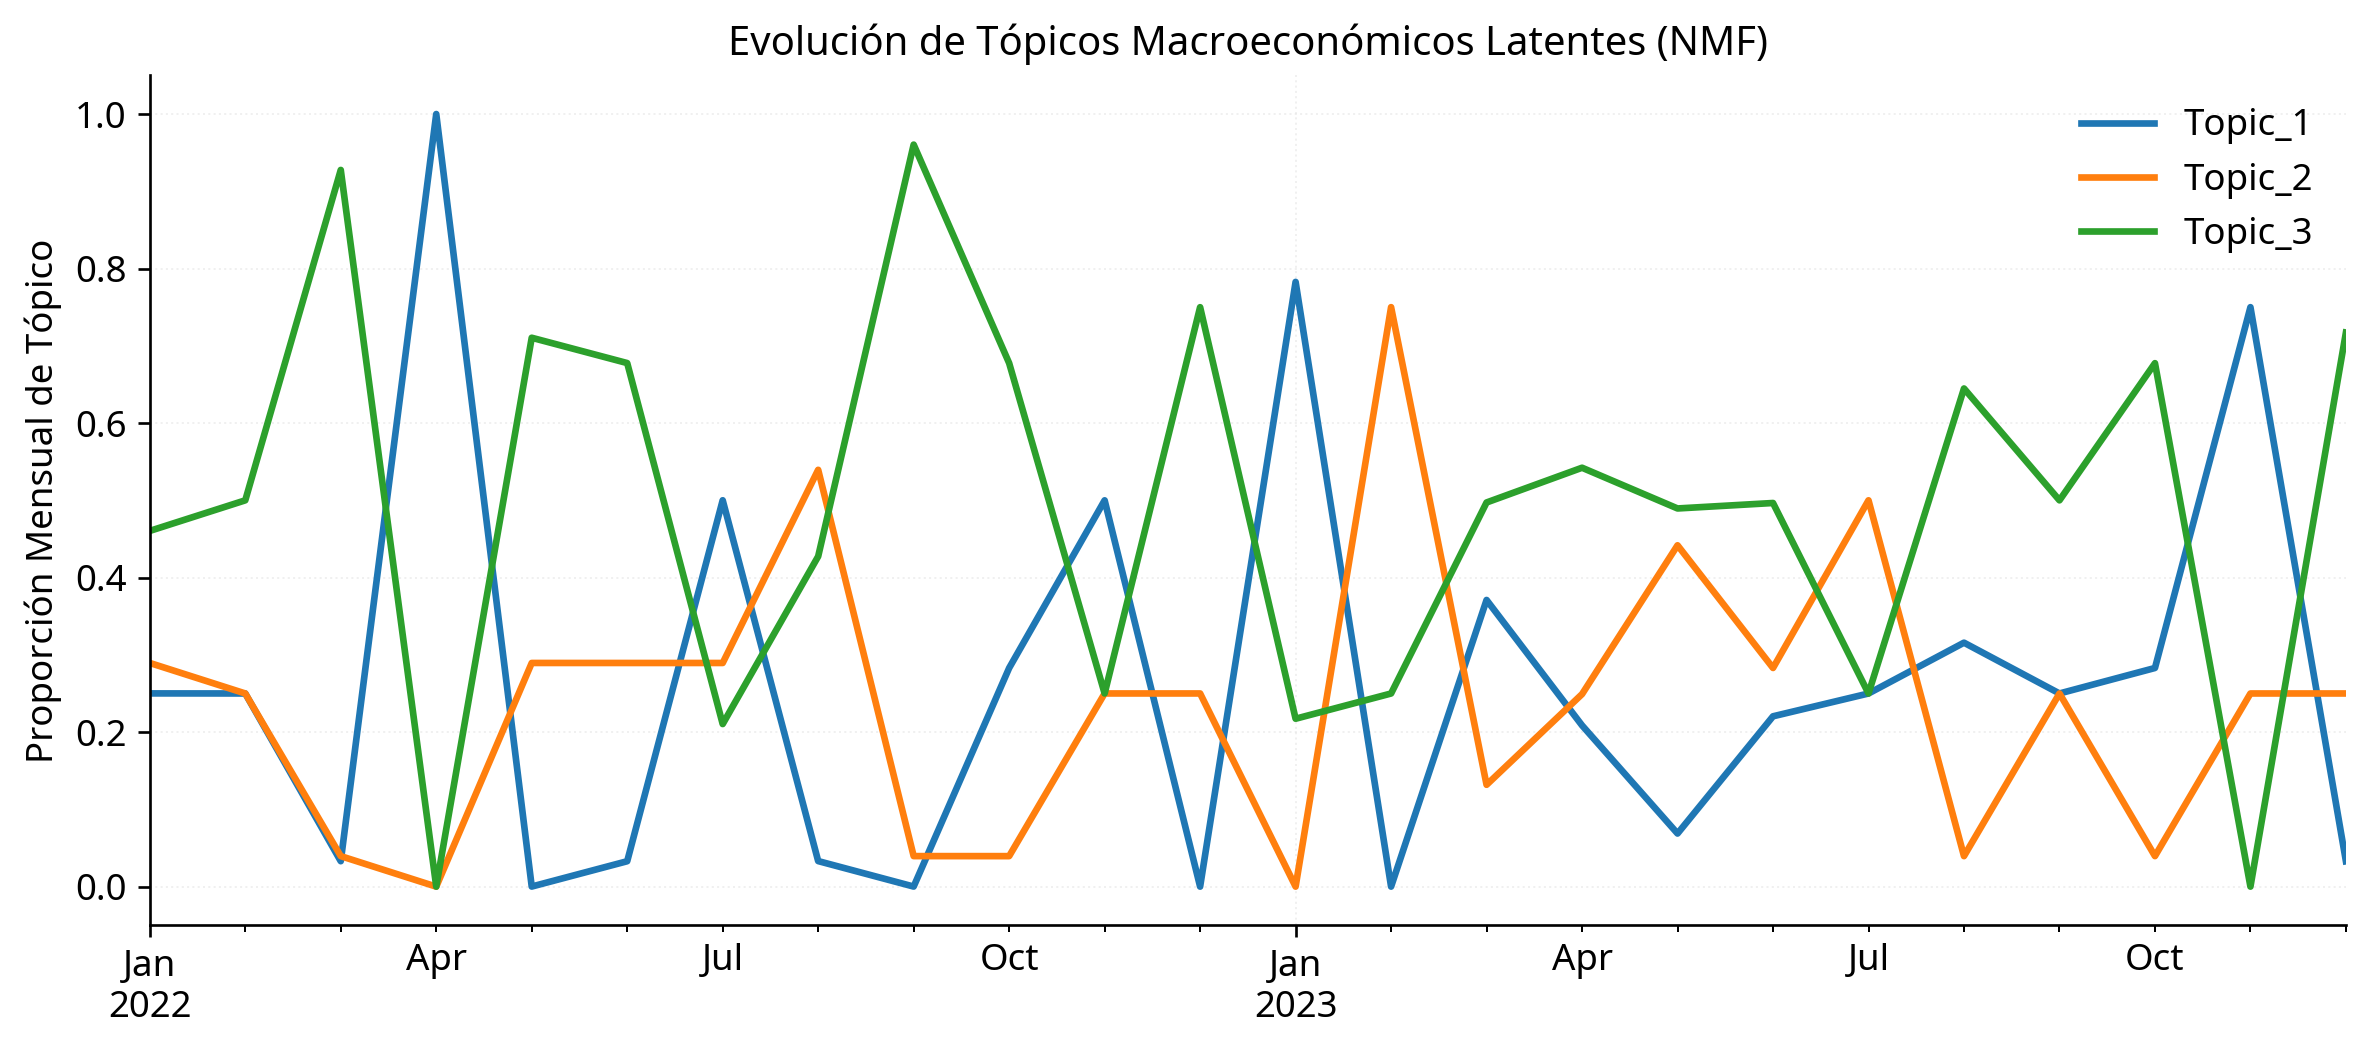

In [3]:
rng = np.random.default_rng(42)
dates = pd.date_range("2022-01-01", periods=24, freq="MS")

corpus_templates = [
    "Presiones inflacionarias elevadas por choques de oferta y precios energéticos.",
    "El banco central incrementa la tasa para anclar las expectativas de inflación.",
    "Condiciones del mercado laboral sólidas con bajo desempleo y presiones salariales.",
    "Estrés en mercados financieros y endurecimiento de condiciones crediticias.",
    "Desaceleración de la actividad económica ante una postura monetaria restrictiva.",
    "Consumo de los hogares resiliente pero desaceleración en inversión fija.",
]

dated_corpus = []
for d in dates:
    for _ in range(4):
        idx = rng.choice(len(corpus_templates))
        text = corpus_templates[idx]
        if pd.Timestamp("2023-03-01") <= d <= pd.Timestamp("2023-06-01"):
            text += " Retiro de depósitos bancarios y volatilidad en el mercado cambiario."
        dated_corpus.append((d, text))

texts_only = [t[1] for t in dated_corpus]
dates_only = [t[0] for t in dated_corpus]

dtm = DynamicTopicModel(n_topics=3, random_state=42)
dtm_res = dtm.fit_transform_corpus(texts_only, dates_only, freq="MS")

fig, ax = plt.subplots(figsize=(10, 4.5))
dtm_res.topic_shares.plot(ax=ax, lw=2)
ax.set_title("Evolución de Tópicos Macroeconómicos Latentes (NMF)", fontsize=12, fontweight="bold")
ax.set_ylabel("Proporción Mensual de Tópico")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Detección de Ráfagas Narrativas Emergentes

In [4]:
target_date = "2023-03-01"
bursts = detect_narrative_bursts(
    dated_corpus,
    target_date=target_date,
    window_periods=12,
    freq="MS",
    min_count=2,
)

print(f"Ráfagas narrativas anómalas detectadas en {target_date}:")
for b in bursts[:5]:
    print(f"  • {b.term:15s} | Z-Score: {b.z_score:+6.2f} | Magnitud de incremento: {b.burst_magnitude:5.1f}x")

Ráfagas narrativas anómalas detectadas en 2023-03-01:
  • retiro          | Z-Score: +9900.99 | Magnitud de incremento: 1000000.0x
  • depósitos       | Z-Score: +9900.99 | Magnitud de incremento: 1000000.0x
  • bancarios       | Z-Score: +9900.99 | Magnitud de incremento: 1000000.0x
  • volatilidad     | Z-Score: +9900.99 | Magnitud de incremento: 1000000.0x
  • cambiario       | Z-Score: +9900.99 | Magnitud de incremento: 1000000.0x


## 4. SVAR Narrativo Bayesiano con Cotas de Ludvigson–Ma–Ng

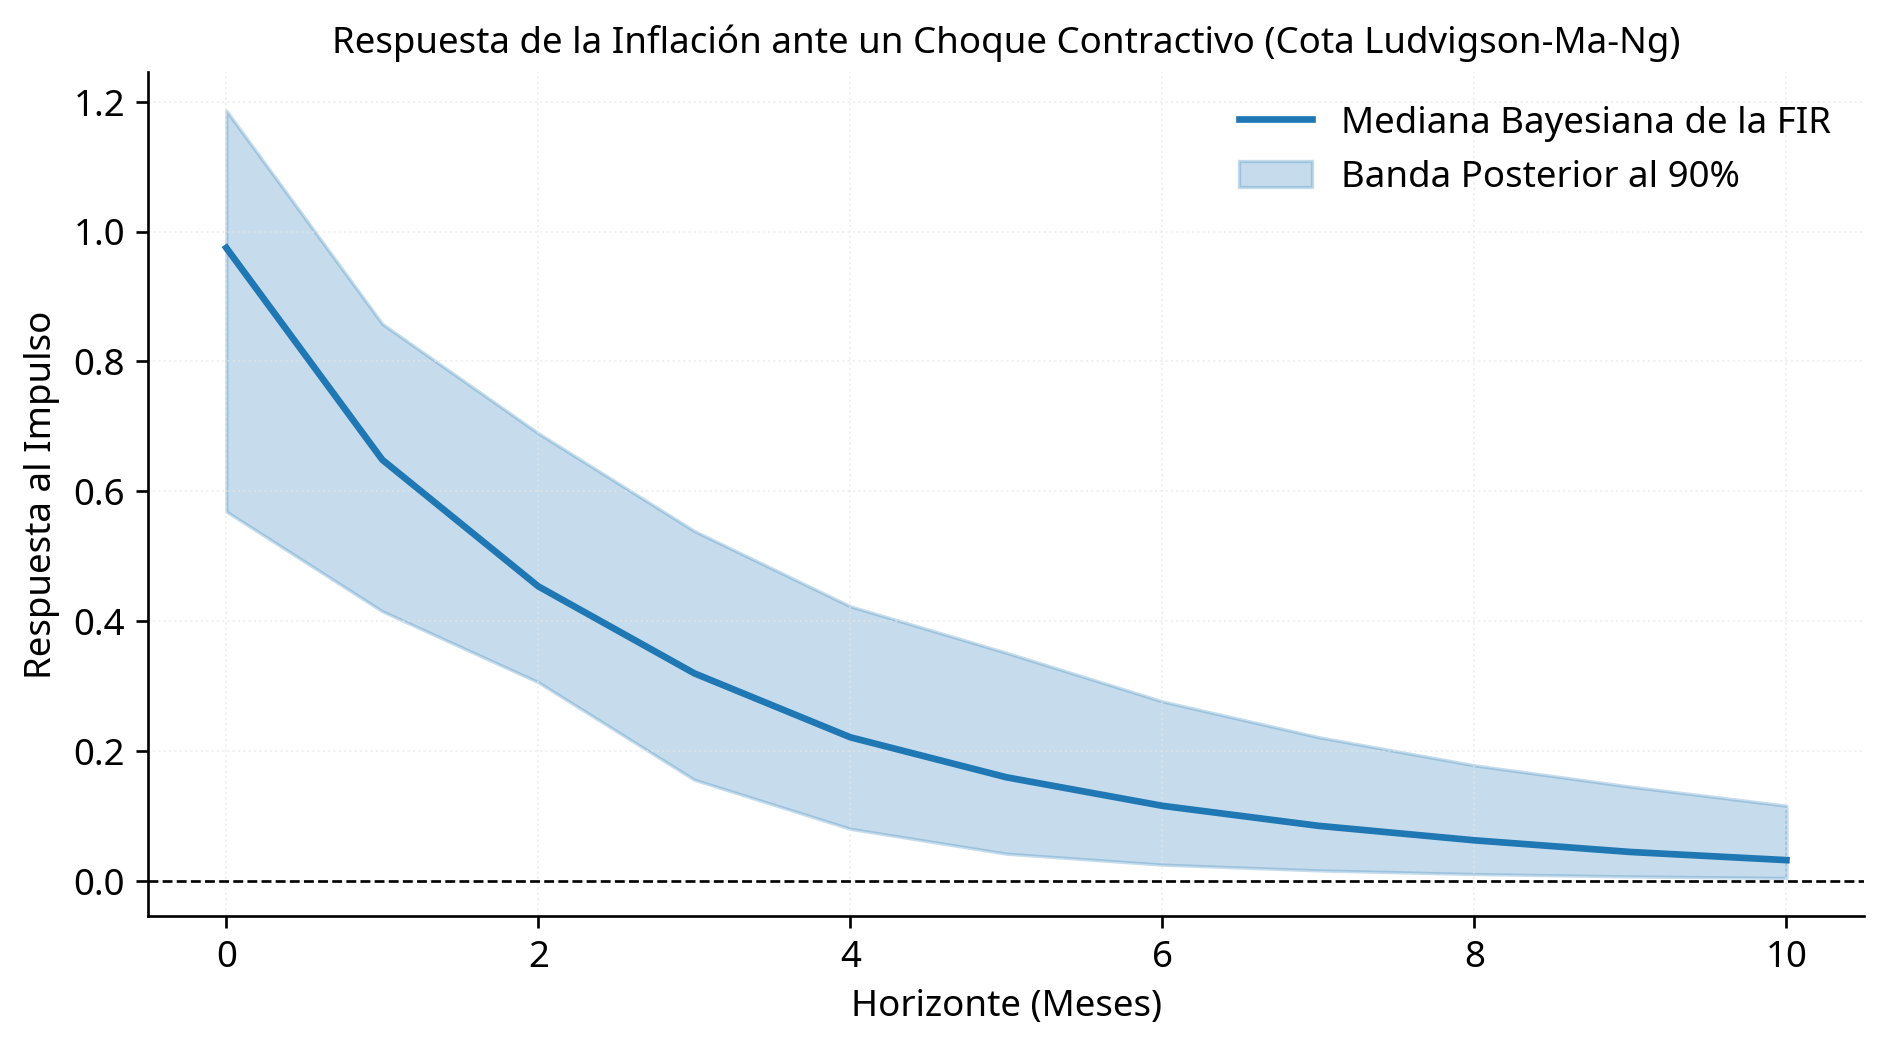

In [5]:
T = 120
e = rng.standard_normal((T, 2))
Y = np.zeros((T, 2))
for t in range(1, T):
    Y[t, 0] = 0.7 * Y[t-1, 0] + 0.1 * Y[t-1, 1] + e[t, 0]
    Y[t, 1] = 0.2 * Y[t-1, 0] + 0.6 * Y[t-1, 1] + 0.5 * e[t, 0] + e[t, 1]

restr = [
    NarrativeRestriction(
        kind="shock_bound",
        date=21,
        shock=0,
        min_magnitude=0.5,
        sign=+1,
    )
]
sign_matrix = {0: np.array([[1, 0], [1, 1]])}

svar_res = narrative_sign_svar(
    Y,
    p=1,
    horizon=10,
    sign_matrix=sign_matrix,
    restrictions=restr,
    bayes_draws=True,
    n_draws=500,
    seed=42,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
h = np.arange(svar_res.irf_median.shape[0])
ax.plot(h, svar_res.irf_median[:, 1, 0], color="#1f77b4", lw=2, label="Mediana Bayesiana de la FIR")
ax.fill_between(h, svar_res.irf_lower[:, 1, 0], svar_res.irf_upper[:, 1, 0], color="#1f77b4", alpha=0.25, label="Banda Posterior al 90%")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_title("Respuesta de la Inflación ante un Choque Contractivo (Cota Ludvigson-Ma-Ng)", fontsize=11, fontweight="bold")
ax.set_xlabel("Horizonte (Meses)")
ax.set_ylabel("Respuesta al Impulso")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()